In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras import regularizers
import random
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
import h5py


In [2]:
def h5_to_dataframe(file_path, dataframe):
    ''' 
    Function for converting h5 file to a pandas dataframe for analysis 
    file_path: path to the h5 file, must be a string
    Dataframe_name: name of the pre-defined dataframe
    
    '''
    with h5py.File(file_path, mode='r') as file:
        tasks_group = file['tasks']
    
        keys = list(tasks_group.keys())
        keys.remove('visc_dissip')
        keys.remove('Reavg')
        time = np.array(file['scales']['sim_time'])
        for key in keys:
            name = np.array(file['tasks'][key][:,0,0])
            #print(name)
            dataframe[key] = name.tolist()

        dataframe['time'] = time.tolist()

    return dataframe

In [3]:
dataframes = []
dataframes2 = []
dataframes3 = []
for exponent in range(4, 9):  # 1e4 to 1e9
    for v in [1, 3, 5, 8]:
        var_name = f"R_{v}e{exponent}"
        globals()[var_name] = pd.DataFrame()
        dataframes.append(globals()[var_name])

        var_name2 = f"R2_{v}e{exponent}"
        globals()[var_name2] = pd.DataFrame()
        dataframes2.append(globals()[var_name2])

        var_name3 = f"R3_{v}e{exponent}"
        globals()[var_name3] = pd.DataFrame()
        dataframes3.append(globals()[var_name3])
        
values = [1, 3, 5, 8]
rayleigh_nums = []
file_path = []
file_path2 = []
file_path3 = []

for power in range(4, 9):  # From 10^4 to 10^9
    base = 10**power
    for v in values:
        rayleigh_nums.append(v * base)
        file_path.append(f"No_slip_data/NS_analysis_{v * base:.0e}/NS_analysis_{v * base:.0e}_s1.h5")
        file_path2.append(f"No_slip_data/NS_analysis2_{v * base:.0e}/NS_analysis2_{v * base:.0e}_s1.h5")
        file_path3.append(f"No_slip_data/NS_analysis3_{v * base:.0e}/NS_analysis3_{v * base:.0e}_s1.h5")


dfs = [dataframes, dataframes2, dataframes3]
file_paths = [file_path, file_path2, file_path3]

for x, df in enumerate(dfs):
    for a, i in enumerate(df):
        h5_to_dataframe(file_paths[x][a], i)


df_clean = []

for df in dfs:
    for x, i in enumerate(df):
        if len(i) == 800:
            Ral_num = np.ones(800)*rayleigh_nums[x]
            i['Ra_num'] = Ral_num.tolist()
            df_clean.append(i)
        else:
            i = i.drop(i.tail(1).index)
            Ral_num = np.ones(800)*rayleigh_nums[x]
            i['Ra_num'] = Ral_num.tolist()
            df_clean.append(i)

In [4]:
data1 = df_clean[:20]

In [5]:
# Merge datasets
data = pd.concat(data1, ignore_index=True)

# Sort data by Rayleigh number and time for consistency
data = data.sort_values(by=["Ra_num", "time"]).reset_index(drop=True)

# Extract the relevant fields (excluding time and Rayleigh number)
target_columns = ["Nusselt", "Re"]
features = ['time', 'Ra_num']
#features = data.columns.drop(target_columns)

# Function to calculate cross-validated test error
def calculate_cv_error(model, X, y, n):
    '''Function to calculate k-fold cv of a model
    model = trained model
    X = features
    y = target
    n = number of splits
    
    '''
    kf = KFold(n_splits=n, shuffle=True, random_state=42)
    mse_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-mse_scores)
    return rmse_scores.mean()


X_train = data[features]
y_train = data['Re']

In [6]:
#SEED = 2

In [7]:
#np.random.seed(SEED)
#tf.random.set_seed(SEED)
#random.seed(SEED)

# Standardize features 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# Log-transform the target and scale it
log_y = np.log1p(y_train)
scaler_y = StandardScaler()
y_train_log = scaler_y.fit_transform(log_y.values.reshape(-1, 1)).flatten()

# Heteroscedastic loss function (adjusted for log-transformed target)
def heteroscedastic_loss(y_true, y_pred):
    mu = y_pred[:, 0]  # Mean prediction (log-space)
    log_var = y_pred[:, 1]
    precision = tf.exp(log_var)  # Inverse variance
    return tf.reduce_mean(0.5 * (tf.math.log(2 * np.pi) + log_var + (y_true - mu) ** 2 / precision))


reg = 0.0001
learn_ra = 0.0001 
# Build the neural network
input_layer = keras.Input(shape=(2,))
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(reg))(input_layer)
#x = layers.Dropout(0.2)(x)  
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(reg))(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(reg))(x)
#x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(reg))(x)
output_layer = layers.Dense(2)(x)  # Two outputs: mean and log variance

model = keras.Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer=keras.optimizers.Adam(learning_rate= learn_ra), loss=heteroscedastic_loss)

# Add early stopping
#early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train_log, epochs=100, batch_size=128)


Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.3172
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0111
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7987
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6703
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5990
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5053
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4069
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2888
Epoch 9/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1667
Epoch 10/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4610
Epoch 11/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0224
Epoch 12/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.0962
Epoch 13/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.1645
Epoch 14/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.1713
Epoch 15/100
125/125 ━━━━━━━━━━━━━━━━━━━

In [8]:
test_df = pd.DataFrame()
path8 = "analysis_1_5e6/analysis15_s1.h5"

test_df = h5_to_dataframe(path8, test_df)
Ral_number = np.ones(800)*1.5e6
test_df['Ra_num'] = Ral_number.tolist()

test_df2 = pd.DataFrame()
path12 = "analysis_7e7/analysis22_s1.h5"

test_df2 = h5_to_dataframe(path12, test_df2)
Ral_number = np.ones(801)*7e7
test_df2['Ra_num'] = Ral_number.tolist()

test_df3 = pd.DataFrame()
path14 = "analysis_2e8/analysis26_s1.h5"

test_df3 = h5_to_dataframe(path14, test_df3)
Ral_number = np.ones(800)*2e8
test_df3['Ra_num'] = Ral_number.tolist()

In [9]:
test_dfs = [test_df, test_df2, test_df3]
y_predictions = []
std_predictions = []
avg_re = []
mae_perc = []
for df in test_dfs:
    X_test = df[features]
    X_test = scaler.transform(X_test)
    y_pred = model.predict(X_test)

    mu_pred, log_var_pred = y_pred[:, 0], y_pred[:, 1]
    sigma_pred = np.exp(log_var_pred / 2)  # Convert log variance to standard deviation
    
    mu_pred = scaler_y.inverse_transform(mu_pred.reshape(-1, 1)).flatten()
    #sigma_pred = scaler_y.inverse_transform(sigma_pred.reshape(-1, 1)).flatten()

    mu_pred = np.expm1(mu_pred)
    mu_pred = np.abs(mu_pred)
    #sigma_pred = np.expm1(sigma_pred)

    y_predictions.append(mu_pred)
    std_predictions.append(sigma_pred)
    MAE = mean_absolute_error(df['Re'], mu_pred)
    print(MAE)
    mean = np.mean(df['Re'])
    avg_re.append(mean)
    mae_perc.append(MAE/mean)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
25.5558569779944
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
126.96920361501734
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
237.70578521888538


In [10]:
print(avg_re)
print(f'average mae error {np.mean(mae_perc)}')

[np.float64(284.17494288985677), np.float64(2470.0710482783466), np.float64(4052.758035581128)]
average mae error 0.06666197224875073


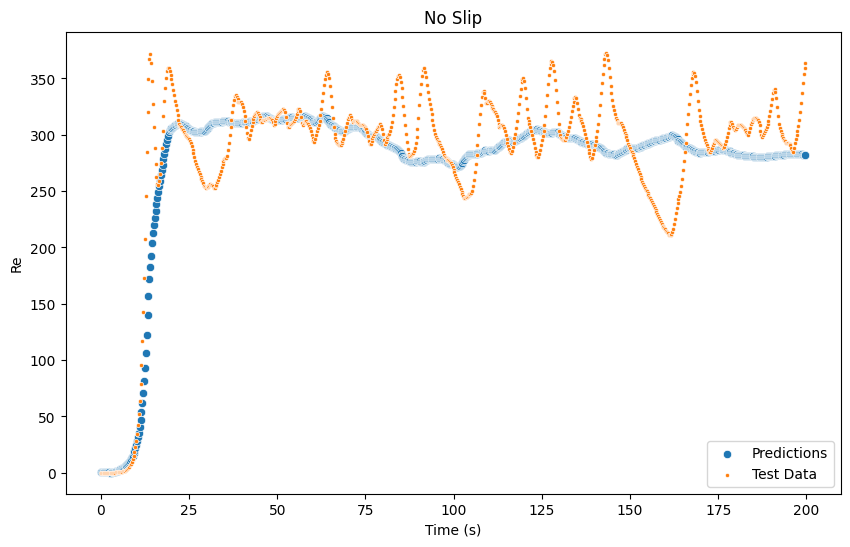

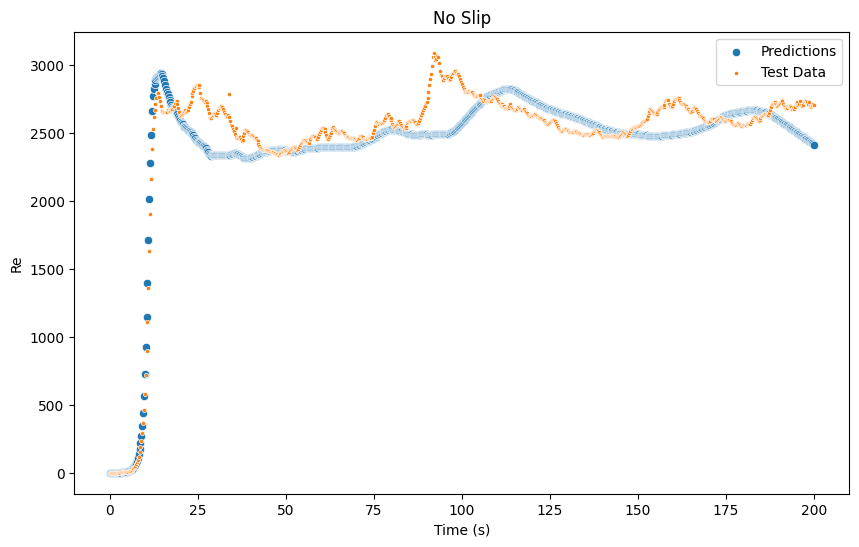

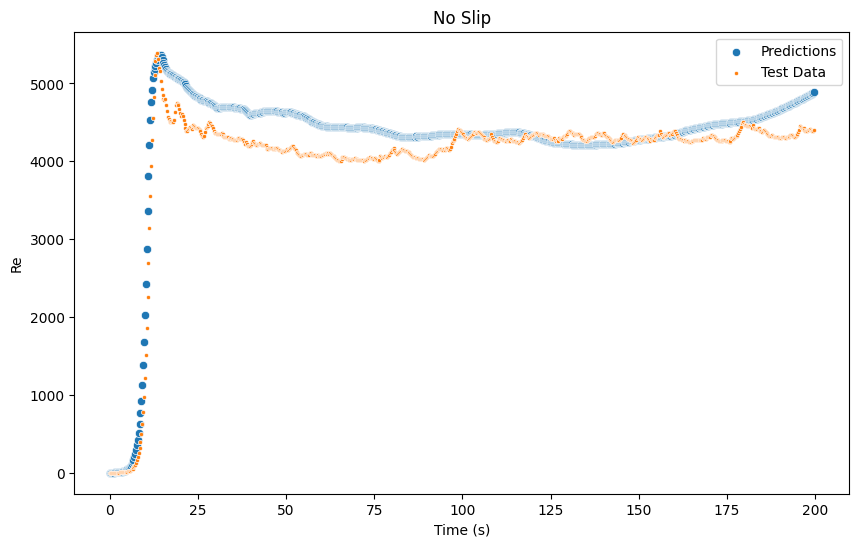

In [17]:
for x, df in enumerate(test_dfs):
    plt.figure(figsize=(10, 6))
    plt.title('No Slip')
    sns.scatterplot(x = df['time'], y = y_predictions[x], marker = 'o', label = 'Predictions')
    sns.scatterplot(x = df['time'], y = df['Re'], marker = '.', label = 'Test Data' )
    plt.xlabel('Time (s)')
    plt.ylabel('Re')
    

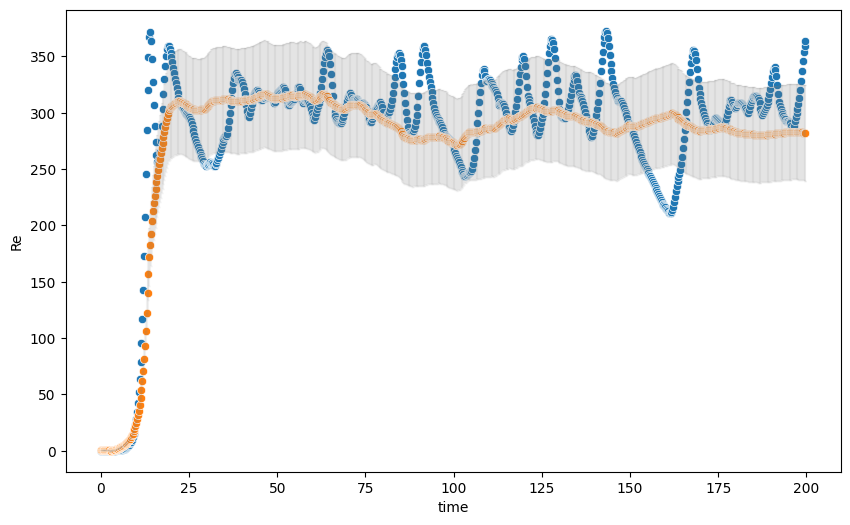

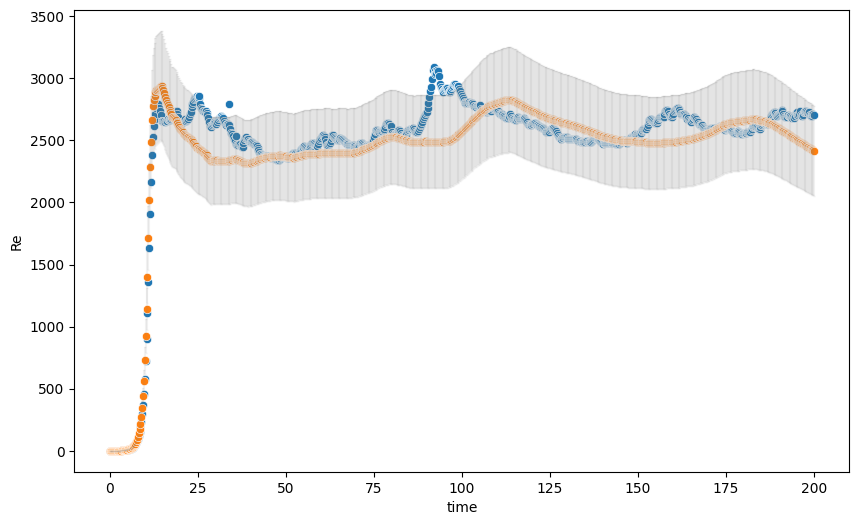

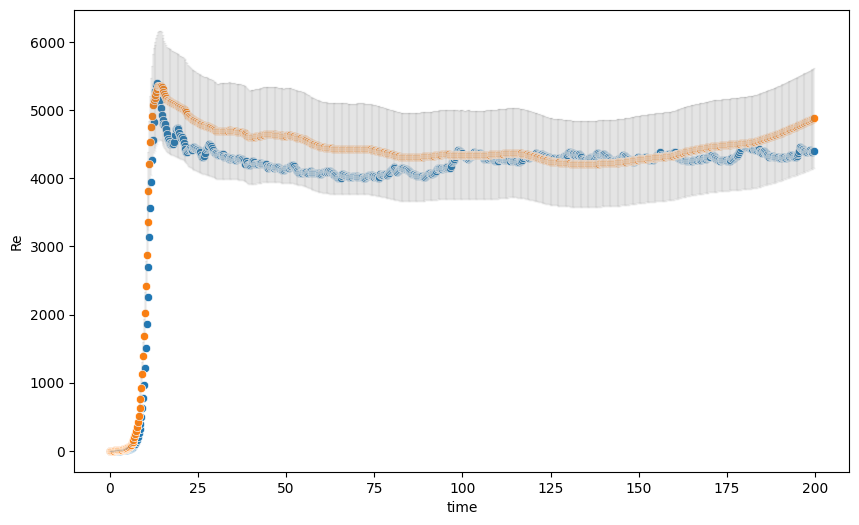

In [12]:
for x, df in enumerate(test_dfs):
    pred = y_predictions[x]
    err = pred*0.15
    plt.figure(figsize=(10, 6))
    plt.errorbar(x = df['time'], y = pred, yerr= err, fmt='none', color='gray', alpha=0.1, capsize=1)
    sns.scatterplot(x = df['time'], y = df['Re'] )
    sns.scatterplot(x = df['time'], y = y_predictions[x])